In [34]:
import sys,os
import joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import classification_report



In [35]:
__script_path=os.path.abspath(globals().get('__file__','.'))
__script_dir = os.path.dirname(__script_path)
root_dir = os.path.abspath(f'{__script_dir}')
print(root_dir)
for lib in [root_dir][::-1]:
    if lib in sys.path:
        sys.path.remove(lib)
    sys.path.insert(0,lib)

from scripts.path_configs import *

/home/dinhtanloc/Projects/loan_ml_prediction_system


In [36]:
# Import Dataset
df=pd.read_csv(f'{data_dir}/loan_data.csv')

tar_column='loan_status'
Num_col=df.select_dtypes('number').columns.tolist()[:-1]
Cat_col=df.select_dtypes('object').columns.tolist()

x_train=pd.read_csv(f"{exps_dir}/x_train.csv", index_col=None)
x_test=pd.read_csv(f"{exps_dir}/x_test.csv", index_col=None)
y_train=pd.read_csv(f"{exps_dir}/y_train.csv", index_col=None)
y_test=pd.read_csv(f"{exps_dir}/y_test.csv", index_col=None)

df_ss=pd.read_csv(f"{exps_dir}/processed_loan_data.csv", index_col=None)

# **4. Modeling ML**

## **Logistic Regression**

In [37]:
from sklearn.linear_model import LogisticRegression

In [38]:
model_li = LogisticRegression()

In [39]:
model_li.fit(x_train, y_train)

/home/dinhtanloc/Projects/loan_ml_prediction_system/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [40]:
y_pred_li = model_li.predict(x_test)

In [41]:
print(classification_report(y_test, y_pred_li))

              precision    recall  f1-score   support

           0       0.92      0.94      0.93      6990
           1       0.77      0.73      0.75      2010

    accuracy                           0.89      9000
   macro avg       0.84      0.83      0.84      9000
weighted avg       0.89      0.89      0.89      9000



## **Decision Tree**

In [42]:
from sklearn.tree import DecisionTreeClassifier

In [43]:
model = DecisionTreeClassifier(max_depth=10)

In [44]:
model.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [45]:
y_pred=model.predict(x_test)

In [46]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.96      0.95      6990
           1       0.85      0.74      0.79      2010

    accuracy                           0.91      9000
   macro avg       0.89      0.85      0.87      9000
weighted avg       0.91      0.91      0.91      9000



## **Grid Search Hyper Para**

In [47]:
!pip show xgboost

/bin/bash: line 1: pip: command not found


In [48]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

In [49]:
param_grid = {
    'n_estimators': [100, 140, 200, 250],
    'max_depth': [5, 8, 12, 16],
    'min_samples_split': [2, 5, 10, 20, 24],
    'max_features': ['sqrt', 'log2', 'auto']
}

In [50]:
grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=50),
    param_grid=param_grid,
    cv=5,
    scoring='f1',  
    n_jobs=-1 
)

In [51]:
# Train
grid_search.fit(x_train, y_train)

/home/dinhtanloc/Projects/loan_ml_prediction_system/.venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [00:39:36] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "max_features", "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/dinhtanloc/Projects/loan_ml_prediction_system/.venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [00:39:36] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "max_features", "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/dinhtanloc/Projects/loan_ml_prediction_system/.venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [00:39:36] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "max_features", "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/dinhtanloc/Projects/loan_ml_prediction_system/.venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [00:39:36] 

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'max_depth': [5, 8, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 140, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [52]:
best_model = grid_search.best_estimator_

In [53]:
y_pred_rf_grid=best_model.predict(x_test)

In [54]:
print(classification_report(y_test, y_pred_rf_grid))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      6990
           1       0.88      0.81      0.84      2010

    accuracy                           0.93      9000
   macro avg       0.91      0.89      0.90      9000
weighted avg       0.93      0.93      0.93      9000



# **5. Deep Learning Method**

## **Pytorch**

In [55]:
import torch
import torch.nn as nn
import torch.optim as optim

### **Pytorch Architecture**

In [56]:
class pytorchnn(nn.Module):
    def __init__(self, input_size, output_size, dropout_rate):
        super(pytorchnn, self).__init__()
        self.fc1 = nn.Linear(input_size, 180)
        self.bn1 = nn.BatchNorm1d(180)  
        self.fc2 = nn.Linear(180, 100)
        self.bn2 = nn.BatchNorm1d(100)
        self.fc3 = nn.Linear(100, 40)
        self.bn3 = nn.BatchNorm1d(40)
        self.fc4 = nn.Linear(40, 8)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc5 = nn.Linear(8, output_size)
        self.dropout = nn.Dropout(dropout_rate)
        self.activation = nn.LeakyReLU(0.1)  

    def forward(self, x):
        out = self.activation(self.bn1(self.fc1(x)))
        out = self.dropout(out)
        out = self.activation(self.bn2(self.fc2(out)))
        out = self.dropout(out)
        out = self.activation(self.bn3(self.fc3(out)))
        out = self.fc4(out)
        out = self.dropout(out)
        out = self.fc5(out)
        return out

### **Setup Hyper Parameter**

In [57]:
input_size= 13
output_size=1
dropout_rate=0.6

### **Khởi tạo DataLoader**

In [58]:
train_data, test_data = train_test_split(df_ss, test_size=0.1, random_state=42)

In [65]:
x_train, x_val, y_train, y_val = train_test_split(train_data.drop(columns=tar_column,axis=1), train_data[tar_column], test_size=0.2, random_state=42)

In [66]:
x_test, y_test = test_data.drop(columns=tar_column,axis=1), test_data[tar_column]

In [67]:
x_train

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
34703,-0.788113,0,0,-0.349235,-0.892284,0,-0.003034,0,-1.392051,0.461810,-0.739109,-1.796534,1
39676,0.204436,1,1,0.167653,0.262171,0,-1.356676,1,-1.190626,-1.487477,0.807419,0.761198,1
20673,1.196985,1,1,-0.523604,1.251705,3,-0.725778,5,1.122406,-0.111509,0.291910,1.554293,0
14896,-0.788113,0,1,0.796315,-0.562440,0,2.283018,4,-1.173840,0.347147,-0.996863,-0.249999,1
38458,0.369861,0,1,-0.190733,0.921860,3,-0.884136,1,-1.462549,-0.914157,0.549665,0.543097,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32684,0.204436,1,1,0.099923,-0.232595,0,3.229839,5,-1.052985,2.296434,0.291910,-0.448272,0
4252,-0.622689,0,1,-0.389386,-0.892284,2,-1.359209,5,-1.425621,-1.372813,-0.739109,-0.606891,1
29300,3.347508,0,3,-0.391861,3.065849,3,1.649588,5,-1.180554,3.099082,1.580683,1.078436,0
18911,0.369861,1,1,-0.254223,-0.232595,3,-1.232523,3,0.236135,-1.258149,-0.223599,0.959472,1


In [68]:
x_val

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
192,-0.622689,1,1,0.015145,-0.727362,3,2.441376,5,-0.005575,1.952442,-0.739109,0.820680,0
5129,-0.788113,1,0,-0.092476,-0.892284,3,-0.092348,3,-1.623689,-0.226173,-0.996863,0.384478,1
42543,0.700710,0,1,-0.241180,0.756938,3,1.702004,5,-1.237625,2.181770,0.549665,0.285341,0
5076,-0.291839,1,1,-0.431887,-0.397517,0,1.016157,0,0.706127,2.411098,-0.996863,0.622406,0
40452,0.700710,1,4,1.026166,0.921860,0,1.311019,2,0.011211,-0.340837,0.549665,1.018954,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
33341,1.031560,0,0,-0.631610,0.592016,3,-0.533374,1,-0.324498,0.805802,2.096192,0.324995,0
3662,-0.788113,0,4,-0.421455,-0.232595,2,1.253693,5,0.034710,2.755090,-0.481354,0.206031,0
31785,1.362410,1,0,1.126301,1.746471,0,-0.567421,2,0.162280,-1.143485,2.611702,0.642234,0
21534,0.535285,1,1,-0.541584,0.097249,3,-0.567421,4,0.746412,0.232483,-0.223599,-1.023266,1


In [69]:
print(x_train.dtypes)


person_age                        float64
person_gender                       int64
person_education                    int64
person_income                     float64
person_emp_exp                    float64
person_home_ownership               int64
loan_amnt                         float64
loan_intent                         int64
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length        float64
credit_score                      float64
previous_loan_defaults_on_file      int64
dtype: object


In [70]:
x_train_tensor = torch.tensor(x_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)

x_val_tensor = torch.tensor(x_val.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32)

x_test_tensor = torch.tensor(x_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

In [71]:
# khởi tạo Dataloader
train_loader = torch.utils.data.DataLoader(
    list(zip(x_train_tensor, y_train_tensor)), batch_size=70, shuffle=True)
val_loader = torch.utils.data.DataLoader(
    list(zip(x_val_tensor, y_val_tensor)), batch_size=70, shuffle=False)
test_loader = torch.utils.data.DataLoader(
    list(zip(x_test_tensor, y_test_tensor)), batch_size=70, shuffle=False)

### **Khởi tạo Model**

In [72]:

model_py = pytorchnn(input_size, output_size, dropout_rate)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_py.parameters(), lr=0.005, weight_decay=1e-5)

# scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                            factor=0.7,
                                                            patience=10,
                                                            min_lr=1e-6)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_py.to(device)

pytorchnn(
  (fc1): Linear(in_features=13, out_features=180, bias=True)
  (bn1): BatchNorm1d(180, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=180, out_features=100, bias=True)
  (bn2): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=100, out_features=40, bias=True)
  (bn3): BatchNorm1d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc4): Linear(in_features=40, out_features=8, bias=True)
  (dropout): Dropout(p=0.6, inplace=False)
  (fc5): Linear(in_features=8, out_features=1, bias=True)
  (activation): LeakyReLU(negative_slope=0.1)
)

### **Train Model**

In [73]:
train_loss_history = []
val_loss_history = []
train_acc_history = []
val_acc_history = []
num_epoch = 500

for epoch in range(num_epoch):
    # Train
    model_py.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for i, (inputs, targets) in enumerate(train_loader):
        inputs = inputs.float().to(device)
        targets = targets.float().to(device).unsqueeze(1)

        # Forward pass
        outputs = model_py(inputs)
        loss = criterion(outputs, targets)

        # Backward và optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        predicted = (torch.sigmoid(outputs) > 0.5).float()
        correct_train += (predicted == targets).sum().item()
        total_train += targets.size(0)

    # Validation
    model_py.eval()
    val_running_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs = inputs.float().to(device)
            targets = targets.float().to(device).unsqueeze(1)

            outputs = model_py(inputs)
            loss = criterion(outputs, targets)
            val_running_loss += loss.item()

            predicted = (torch.sigmoid(outputs) > 0.5).float()
            correct_val += (predicted == targets).sum().item()
            total_val += targets.size(0)

    avg_train_loss = running_loss / len(train_loader)
    avg_val_loss = val_running_loss / len(val_loader)
    train_acc = correct_train / total_train * 100  
    val_acc = correct_val / total_val * 100        

    scheduler.step(avg_val_loss)

    train_loss_history.append(avg_train_loss)
    val_loss_history.append(avg_val_loss)
    train_acc_history.append(train_acc)  
    val_acc_history.append(val_acc)      

    if epoch % 10 == 0:
       print(f"Epoch [{epoch+1}/{num_epoch}]: Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}% | Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%")

Epoch [1/500]: Train Loss: 0.2958, Train Acc: 86.31% | Val Loss: 0.2330, Val Acc: 89.54%
Epoch [11/500]: Train Loss: 0.2390, Train Acc: 89.11% | Val Loss: 0.2197, Val Acc: 89.67%
Epoch [21/500]: Train Loss: 0.2348, Train Acc: 89.45% | Val Loss: 0.2034, Val Acc: 91.16%
Epoch [31/500]: Train Loss: 0.2340, Train Acc: 89.42% | Val Loss: 0.2125, Val Acc: 90.52%
Epoch [41/500]: Train Loss: 0.2344, Train Acc: 89.47% | Val Loss: 0.2004, Val Acc: 90.72%
Epoch [51/500]: Train Loss: 0.2305, Train Acc: 89.62% | Val Loss: 0.1982, Val Acc: 91.31%
Epoch [61/500]: Train Loss: 0.2286, Train Acc: 89.74% | Val Loss: 0.1982, Val Acc: 91.43%
Epoch [71/500]: Train Loss: 0.2278, Train Acc: 89.70% | Val Loss: 0.1921, Val Acc: 91.41%
Epoch [81/500]: Train Loss: 0.2285, Train Acc: 89.80% | Val Loss: 0.1992, Val Acc: 91.28%
Epoch [91/500]: Train Loss: 0.2262, Train Acc: 89.84% | Val Loss: 0.1963, Val Acc: 91.42%
Epoch [101/500]: Train Loss: 0.2231, Train Acc: 90.04% | Val Loss: 0.1937, Val Acc: 91.43%
Epoch [111

In [74]:
# Last record: Opti Adam, LR=0.004, Batch 70

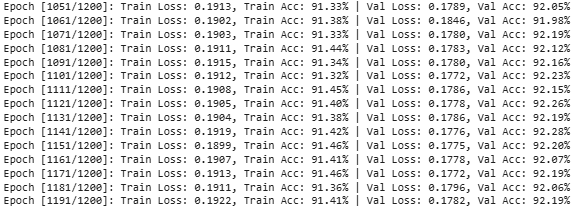

In [75]:

def get_predictions(model, data_loader):
    model.eval()  # Set model to evaluation mode
    predictions = []
    actuals = []
    with torch.no_grad():  # Disable gradient calculation
        for inputs, targets in data_loader:
            inputs = inputs.float().to(device)
            targets = targets.to(device)

            # Forward pass to get outputs
            outputs = model(inputs)

            # Move outputs and targets to CPU and convert to numpy arrays
            predictions.extend(outputs.cpu().numpy())
            actuals.extend(targets.cpu().numpy())

    # Convert lists to numpy arrays for easy handling
    predictions = np.array(predictions).squeeze()
    actuals = np.array(actuals).squeeze().astype(int)

    return predictions, actuals

In [76]:
predictions, actuals = get_predictions(model_py, test_loader)

In [77]:
predictions_binary = np.where(predictions > 0.5, 1, 0)

In [78]:
print(classification_report(actuals, predictions_binary))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94      3444
           1       0.91      0.64      0.75      1056

    accuracy                           0.90      4500
   macro avg       0.91      0.81      0.85      4500
weighted avg       0.90      0.90      0.89      4500



# **6. Download the model**

In [79]:
joblib.dump(best_model, f'{exps_dir}/model_ml.joblib')

['/home/dinhtanloc/Projects/loan_ml_prediction_system/exps/model_ml.joblib']